# **PART 1: IMPORTING**

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import math

# 1. PORTFOLIO CONFIGURATION
tickers = [
    'AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS',
    'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT',
    'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WMT', 'AMZN', 'NVDA', 'SHW'
]

CAPITAL = 50_000_000
TARGET_EQ_W = 0.95
TARGET_FUT_CASH_W = 0.05
FUT_EXPOSURE_VAL_START = 2_500_000

MARGIN_RATE = 0.04
FUT_MULT = 5
FEE_TX = 0.01
FEE_MGT = 0.0016
FEE_PERF = 0.00

START_DT = '2025-05-01'
REBAL_DT = '2025-11-01'
END_DT   = '2026-05-01'

FUTURES_NAME = "E-mini Dow Jones ($5) Futures (Ticker: YM - Exchange: CBOT)"
FUTURES_LINK = "https://www.investing.com/indices/us-30-futures"

print("Downloading live data from Yahoo Finance...")
data = yf.download(
    tickers + ['^DJI', 'YM=F'],
    start=START_DT,
    end=END_DT,
    progress=False
)['Close']
data = data.ffill().dropna()



/tmp/ipykernel_3339/3123961047.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(


# **PART 2: PROCESSING**

In [2]:
# 2. PORTFOLIO INCEPTION (01/05/2025)
p0 = data.iloc[0]
djia_start_price = p0['^DJI']
fut_start_price = p0['YM=F']
sum_p0 = p0[tickers].sum()

budget_eq = CAPITAL * TARGET_EQ_W
budget_fut_cash = CAPITAL * TARGET_FUT_CASH_W

# Number of shares per ticker (Price-weighted, including 1% transaction fee)
shares = math.floor(budget_eq / (sum_p0 * (1 + FEE_TX)))
cost_eq = shares * sum_p0
fee_eq_0 = cost_eq * FEE_TX
cash_from_eq = budget_eq - cost_eq - fee_eq_0

# Futures position sizing based on Hedge Ratio
notional_1_contract = fut_start_price * FUT_MULT
num_contracts = round(FUT_EXPOSURE_VAL_START / notional_1_contract)
margin_req = num_contracts * notional_1_contract * MARGIN_RATE
free_cash = budget_fut_cash + cash_from_eq - margin_req

print(f"\n========== FUTURES CONTRACT INFORMATION ==========")
print(f"Contract name: {FUTURES_NAME}")
print(f"Reference link: {FUTURES_LINK}")
print(f"Multiplier: ${FUT_MULT} / index point")

print(f"\n========== INCEPTION DATE: {START_DT} ==========")
print(f"Initial capital: ${CAPITAL:,.2f}")
print(f"Equity budget: ${budget_eq:,.2f}")
print(f"Futures cash budget: ${budget_fut_cash:,.2f}")
print(f"\n--- PORTFOLIO INCEPTION ON {START_DT} ---")
print(f"Sum of 30 stock prices: ${sum_p0:,.2f}")
print(f"Number of shares per ticker: {shares:,} shares")
print(f"Actual equity cost: ${cost_eq:,.2f}")
print(f"Remaining cash from equity purchase: ${cash_from_eq:,.2f}")
print(f"DJIA price: {djia_start_price:,.2f}")
print(f"Notional value per contract: ${notional_1_contract:,.2f}")
print(f"Number of Futures contracts ({FUTURES_NAME}) selected by Hedge Ratio: {num_contracts} contracts")
print(f"Margin requirement held (4%): ${margin_req:,.2f}")
print(f"Free cash after Futures purchase: ${free_cash:,.2f}")




========== FUTURES CONTRACT INFORMATION ==========
Contract name: E-mini Dow Jones ($5) Futures (Ticker: YM - Exchange: CBOT)
Reference link: https://www.investing.com/indices/us-30-futures
Multiplier: $5 / index point

========== INCEPTION DATE: 2025-05-01 ==========
Initial capital: $50,000,000.00
Equity budget: $47,500,000.00
Futures cash budget: $2,500,000.00

--- PORTFOLIO INCEPTION ON 2025-05-01 ---
Sum of 30 stock prices: $6,491.61
Number of shares per ticker: 7,244 shares
Actual equity cost: $47,025,194.93
Remaining cash from equity purchase: $4,553.12
DJIA price: 40,752.96
Notional value per contract: $204,275.00
Number of Futures contracts (E-mini Dow Jones ($5) Futures (Ticker: YM - Exchange: CBOT)) selected by Hedge Ratio: 12 contracts
Margin requirement held (4%): $98,052.00
Free cash after Futures purchase: $2,406,501.12


In [3]:
# 3. PORTFOLIO REBALANCING (01/11/2025)
p_rebal = data.loc[data.index.asof(REBAL_DT)]
actual_rebal_dt = p_rebal.name
djia_rebal = p_rebal['^DJI']
fut_rebal_price = p_rebal['YM=F']
sum_p_rebal = p_rebal[tickers].sum()

# DOWNLOAD DIVIDEND DATA DAILY
dividend_timeline = pd.Series(0.0, index=data.index)
for t in tickers:
    div_series = yf.Ticker(t).dividends
    if not div_series.empty:
        div_series.index = div_series.index.tz_localize(None)
        # Filter dividends generated across the entire data timeframe
        div_series = div_series[(div_series.index >= data.index[0]) & (div_series.index <= data.index[-1])]
        for div_date, div_val in div_series.items():
            # Find the nearest trading date that matches or immediately follows the dividend payment date in the index data.
            matched_idx = data.index[data.index >= div_date]
            if not matched_idx.empty:
                actual_data_date = matched_idx[0]
                # In phase 1 (before/on the Rebalance date), use the number of 'shares'
                # In phase 2 (after the Rebalance date), use the number of 'new_shares' (this will be calculated dynamically in the next loop).
                if actual_data_date <= actual_rebal_dt:
                    dividend_timeline.loc[actual_data_date] += div_val * shares

# Total dividends received from 01/05 to 01/11/2025 for calculating Rebalance
total_div = dividend_timeline.loc[:actual_rebal_dt].sum()

# Portfolio value before executing Rebalance orders
current_eq_val = shares * sum_p_rebal
fut_pnl_1 = num_contracts * (fut_rebal_price - fut_start_price) * FUT_MULT
total_cash_pre = free_cash + margin_req + fut_pnl_1 + total_div
total_money_rebal = current_eq_val + total_cash_pre
current_eq_w = current_eq_val / total_money_rebal

print(f"\n========== REBALANCING DATE: {actual_rebal_dt.date()} ==========")
print(f"Total dividends received from portfolio: ${total_div:,.2f}")
print(f"Total portfolio value at rebalancing date: ${total_money_rebal:,.2f}")
print(f"Current available cash (Total pre-cash): ${total_cash_pre:,.2f}")
print(f"Current Equity weight before Rebalance: {current_eq_w*100:.2f}%")
print(f"-> Current shares per ticker (Before Rebalance): {shares:,} shares")

# Adjust equity structure back to target weight
target_eq_val = total_money_rebal * TARGET_EQ_W
new_shares = round(target_eq_val / sum_p_rebal)

shares_diff = new_shares - shares
trade_value = abs(shares_diff) * sum_p_rebal
fee_rebal = trade_value * FEE_TX

# Separate actual available cash from margin/derivative PnL positions to calculate standard weighting.
free_cash_new_tmp = total_cash_pre - (shares_diff * sum_p_rebal) - fee_rebal - margin_req - fut_pnl_1
actual_equity_val_after = new_shares * sum_p_rebal
futures_current_asset = margin_req + fut_pnl_1
total_assets_after_check = actual_equity_val_after + free_cash_new_tmp + futures_current_asset

actual_eq_weight_after = actual_equity_val_after / total_assets_after_check

# PRINTING INFORMATION ON SHARE QUANTITIES CHANGES
print(f"-> New target shares per ticker (After Rebalance): {new_shares:,} shares")
if shares_diff > 0:
    print(f"-> Action: BUY additional {shares_diff:,} shares for EACH of the 30 tickers.")
elif shares_diff < 0:
    print(f"-> Action: SELL {abs(shares_diff):,} shares from EACH of the 30 tickers.")
else:
    print(f"-> Action: NO equity trades required. Target weight perfectly maintained.")

print(f"-> Buy/sell orders executed. Transaction fee incurred (1%): ${fee_rebal:,.2f}")
print(f"-> Equity weight check after adjustment: {actual_eq_weight_after*100:.2f}% (Target: {TARGET_EQ_W*100:.2f}%)")

# Adjust Futures position based on new total assets (5% of new AUM)
target_fut_exposure = total_money_rebal * TARGET_FUT_CASH_W
new_notional_1 = fut_rebal_price * FUT_MULT
num_contracts_target = round(target_fut_exposure / new_notional_1)

contracts_diff = num_contracts_target - num_contracts
margin_per_contract = new_notional_1 * MARGIN_RATE
required_additional_margin = contracts_diff * margin_per_contract

# Restore the cash fund, including the old Margin and PnL, to redistribute to the new Futures.
cash_available_for_futures = free_cash_new_tmp + futures_current_asset

if cash_available_for_futures >= (num_contracts_target * margin_per_contract):
    print(f"Available cash is SUFFICIENT to adjust Futures contracts.")
    print(f"Net change in contracts: {contracts_diff} contracts")
    num_contracts_new = num_contracts_target
    margin_req_new = num_contracts_new * margin_per_contract
    free_cash_new = cash_available_for_futures - margin_req_new
else:
    print(f"Available cash is INSUFFICIENT. Maintaining current Futures contracts.")
    num_contracts_new = num_contracts
    margin_req_new = margin_req
    free_cash_new = cash_available_for_futures - margin_req_new

print(f"Total Futures contracts ({FUTURES_NAME}) held after Rebalance: {num_contracts_new} contracts")
print(f"Free cash after adding contracts: ${free_cash_new:,.2f}")

# DIVIDEND VALUE FOR PHASE 2 UPDATED
for t in tickers:
    div_series = yf.Ticker(t).dividends
    if not div_series.empty:
        div_series.index = div_series.index.tz_localize(None)
        div_series = div_series[(div_series.index > actual_rebal_dt) & (div_series.index <= data.index[-1])]
        for div_date, div_val in div_series.items():
            matched_idx = data.index[data.index >= div_date]
            if not matched_idx.empty:
                actual_data_date = matched_idx[0]
                dividend_timeline.loc[actual_data_date] += div_val * new_shares


========== REBALANCING DATE: 2025-10-31 ==========
Total dividends received from portfolio: $445,897.65
Total portfolio value at rebalancing date: $58,756,958.14
Current available cash (Total pre-cash): $3,362,470.77
Current Equity weight before Rebalance: 94.28%
-> Current shares per ticker (Before Rebalance): 7,244 shares
-> New target shares per ticker (After Rebalance): 7,300 shares
-> Action: BUY additional 56 shares for EACH of the 30 tickers.
-> Buy/sell orders executed. Transaction fee incurred (1%): $4,282.29
-> Equity weight check after adjustment: 95.01% (Target: 95.00%)
Available cash is SUFFICIENT to adjust Futures contracts.
Net change in contracts: 0 contracts
Total Futures contracts (E-mini Dow Jones ($5) Futures (Ticker: YM - Exchange: CBOT)) held after Rebalance: 12 contracts
Free cash after adding contracts: $2,815,426.62


In [4]:
# 4. DAILY NAV SIMULATION FOR TRACKING ERROR

daily_nav_series = []
accumulated_div_run = 0.0

for idx in range(len(data)):
    current_date = data.index[idx]
    p_t = data.iloc[idx]
    djia_t = p_t['^DJI']
    fut_t = p_t['YM=F']
    sum_p_t = p_t[tickers].sum()

    # Accumulate the actual dividends paid on that day.
    accumulated_div_run += dividend_timeline.loc[current_date]

    if current_date <= actual_rebal_dt:
        eq_v = shares * sum_p_t
        fut_pnl = num_contracts * (fut_t - fut_start_price) * FUT_MULT
        # Add the accumulated dividends up to date to your idle cash fund instead of waiting 6 months.
        nav_t = eq_v + (free_cash + accumulated_div_run) + margin_req + fut_pnl
    else:
        eq_v = new_shares * sum_p_t
        fut_pnl = num_contracts_new * (fut_t - fut_rebal_price) * FUT_MULT
        # Any accumulated dividends after the rebalance date will be carried over.
        div_post_rebal = accumulated_div_run - total_div
        nav_t = eq_v + (free_cash_new + div_post_rebal) + margin_req_new + fut_pnl
    daily_nav_series.append(nav_t)

df_returns = pd.DataFrame(index=data.index)
df_returns['NAV'] = daily_nav_series
df_returns['Port_Return'] = df_returns['NAV'].pct_change()
df_returns['Benchmark_Return'] = data['^DJI'].pct_change()
df_returns = df_returns.dropna()

In [5]:
# 5. END DATE AND EVALUATION (01/05/2026)

p_end = data.iloc[-1]
djia_end = p_end['^DJI']
fut_end_price = p_end['YM=F']

final_equity_value = new_shares * p_end[tickers].sum()
final_futures_pnl = num_contracts_new * (fut_end_price - fut_rebal_price) * FUT_MULT
gross_portfolio_value = final_equity_value + free_cash_new + margin_req_new + final_futures_pnl

# Because the accumulated dividends from phase 2 have been directly included in the daily NAV,
# The gross_portfolio_value at the end of the period needs to include accumulated dividends after the Rebalance date for synchronization.
total_div_period_2 = accumulated_div_run - total_div
gross_portfolio_value += total_div_period_2

management_fee = gross_portfolio_value * FEE_MGT
portfolio_gross_return = (gross_portfolio_value / CAPITAL) - 1
benchmark_total_return = (djia_end / djia_start_price) - 1

performance_fee = 0
print(f"\n========== END DATE: {END_DT} ==========")
if portfolio_gross_return > benchmark_total_return:
    print(f"-> Notice: Portfolio OUTPERFORMS DJIA (+{(portfolio_gross_return - benchmark_total_return)*100:.2f}%). Performance fee is 0%.")
    performance_fee = gross_portfolio_value * FEE_PERF
else:
    print("-> Notice: Portfolio UNDERPERFORMS or MATCHES DJIA. No performance fee applied.")

net_portfolio_value = gross_portfolio_value - management_fee - performance_fee
portfolio_net_return = (net_portfolio_value / CAPITAL) - 1

tracking_error_val = np.std(df_returns['Port_Return'] - df_returns['Benchmark_Return']) * np.sqrt(252)
print(f"Equity value before fees: ${final_equity_value:,.2f}")
print(f"Futures P&L before fees (Gross NAV): ${final_futures_pnl:,.2f}")
print(f"Portfolio value before fees (Gross NAV): ${gross_portfolio_value:,.2f}")
print(f"Management fee deducted (0.16%): ${management_fee:,.2f}")
print(f"Performance fee deducted (0%): ${performance_fee:,.2f}")
print(f"Final Net Asset Value of the fund (Net NAV): ${net_portfolio_value:,.2f}")
print(f"\n--- PERFORMANCE EVALUATION METRICS ---")
print(f"Portfolio Return (Net Return): {portfolio_net_return*100:.2f}%")
print(f"Benchmark Return (DJIA): {benchmark_total_return*100:.2f}%")


========== END DATE: 2026-05-01 ==========
-> Notice: Portfolio OUTPERFORMS DJIA (+2.73%). Performance fee is 0%.
Equity value before fees: $58,751,567.83
Futures P&L before fees (Gross NAV): $126,780.00
Portfolio value before fees (Gross NAV): $62,281,442.15
Management fee deducted (0.16%): $99,650.31
Performance fee deducted (0%): $0.00
Final Net Asset Value of the fund (Net NAV): $62,181,791.85

--- PERFORMANCE EVALUATION METRICS ---
Portfolio Return (Net Return): 24.36%
Benchmark Return (DJIA): 21.84%


In [6]:
# 6. ADDITIONAL RISK AND PERFORMANCE METRICS

RISK_FREE_RATE = 0.044

# Prepare daily NET return series
total_days = len(df_returns)
daily_mgmt_fee_rate = FEE_MGT / 252

df_risk = df_returns.copy()
df_risk['Gross_NAV'] = df_risk['NAV']
df_risk['Cumulative_Fee_Factor'] = (1 - daily_mgmt_fee_rate) ** np.arange(1, total_days + 1)
df_risk['Net_NAV'] = df_risk['Gross_NAV'] * df_risk['Cumulative_Fee_Factor']
df_risk['Net_Return'] = df_risk['Net_NAV'].pct_change().dropna()

df_risk_clean = df_risk.dropna(subset=['Net_Return'])

port_net_returns  = df_risk_clean['Net_Return']
bench_returns     = df_risk_clean['Benchmark_Return']
rf_daily          = RISK_FREE_RATE / 252


# VOLATILITY (Annualized)
port_vol   = port_net_returns.std()  * np.sqrt(252)
bench_vol  = bench_returns.std()     * np.sqrt(252)


# SHARPE RATIO (Net Return, annualized)
port_excess_mean   = (port_net_returns  - rf_daily).mean() * 252
bench_excess_mean  = (bench_returns     - rf_daily).mean() * 252

sharpe_port  = port_excess_mean  / port_vol
sharpe_bench = bench_excess_mean / bench_vol


# BETA (Portfolio vs DJIA)

cov_matrix   = np.cov(port_net_returns, bench_returns)
beta_port    = cov_matrix[0, 1] / cov_matrix[1, 1]

# MAXIMUM DRAWDOWN & FIND DATE
def max_drawdown_with_date(return_series):
    cum = (1 + return_series).cumprod()
    rolling_max = cum.cummax()
    drawdown = (cum - rolling_max) / rolling_max
    mdd_val = drawdown.min()
    mdd_date = drawdown.idxmin()
    return mdd_val, mdd_date

mdd_port, mdd_port_date = max_drawdown_with_date(port_net_returns)
mdd_bench, mdd_bench_date = max_drawdown_with_date(bench_returns)

# TRACKING ERROR (Annualized)
active_return  = port_net_returns - bench_returns
tracking_error_net = active_return.std() * np.sqrt(252)


# PRINT RESULTS
print(f"\n--- ADDITIONAL RISK AND PERFORMANCE METRICS (vs DJIA) ---")
print(f"{'Metric':<45} {'Portfolio':>15} {'DJIA Benchmark':>18}")
print("-" * 80)
print(f"{'Volatility (Annualized)':<45} {port_vol*100:>14.2f}% {bench_vol*100:>17.2f}%")
print(f"{'Sharpe Ratio (Rf = 4.4%)':<45} {sharpe_port:>15.4f} {sharpe_bench:>18.4f}")
print(f"{'Beta (vs DJIA)':<45} {beta_port:>15.4f} {'1.0000':>18}")
print(f"{'Maximum Drawdown':<45} {mdd_port*100:>14.2f}% {mdd_bench*100:>17.2f}%")
print(f"{'Tracking Error Annualized (Net vs DJIA)':<45} {tracking_error_net*100:>14.4f}%")


--- ADDITIONAL RISK AND PERFORMANCE METRICS (vs DJIA) ---
Metric                                              Portfolio     DJIA Benchmark
--------------------------------------------------------------------------------
Volatility (Annualized)                                12.47%             12.52%
Sharpe Ratio (Rf = 4.4%)                               1.4377             1.1908
Beta (vs DJIA)                                         0.9955             1.0000
Maximum Drawdown                                       -9.43%            -10.01%
Tracking Error Annualized (Net vs DJIA)               0.4033%


In [7]:
# 7. ADDITIONAL PERFORMANCE BREAKDOWN TABLE

print("\n" + "="*80)
print(f"{'AG CAPITAL - PORTFOLIO COMPONENT PERFORMANCE':^80}")
print("="*80)

# Calculate breakdown values using existing variables
# 1. Net profit in absolute cash value
total_equity_div = dividend_timeline.sum()
equity_capital_gain = final_equity_value - cost_eq
equity_profit_money = equity_capital_gain + total_equity_div

futures_profit_money = fut_pnl_1 + final_futures_pnl

# 2. Initial allocated capital
equity_initial_invest = budget_eq
futures_initial_invest = budget_fut_cash

# 3. Component percentage return
equity_return_pct = (equity_profit_money / equity_initial_invest) * 100
futures_return_pct = (futures_profit_money / futures_initial_invest) * 100

# 4. Benchmark Return
benchmark_return_pct = benchmark_total_return * 100

# Print results
print(f"{'Performance Metrics':<38} | {'Equity Portfolio':<18} | {'Futures & Cash':<18}")
print("-" * 80)
print(f"{'1. Net Profit (Absolute USD)':<38} | {f'${equity_profit_money:,.2f}':>18} | {f'${futures_profit_money:,.2f}':>18}")
print(f"{'2. Initial Capital Allocation':<38} | {f'${equity_initial_invest:,.2f}':>18} | {f'${futures_initial_invest:,.2f}':>18}")
print(f"{'3. Component Return (%)':<38} | {equity_return_pct:>17.2f}% | {futures_return_pct:>17.2f}%")
print("-" * 80)
print(f"{'4. DJIA Benchmark Return':<38} | {f'=== {benchmark_return_pct:.2f}% (Shared Benchmark Index) ===':^41}")
print("="*80)


                  AG CAPITAL - PORTFOLIO COMPONENT PERFORMANCE                  
Performance Metrics                    | Equity Portfolio   | Futures & Cash    
--------------------------------------------------------------------------------
1. Net Profit (Absolute USD)           |     $12,645,405.45 |        $538,800.00
2. Initial Capital Allocation          |     $47,500,000.00 |      $2,500,000.00
3. Component Return (%)                |             26.62% |             21.55%
--------------------------------------------------------------------------------
4. DJIA Benchmark Return               |  === 21.84% (Shared Benchmark Index) === 


# **PART 3: VISUALIZING**

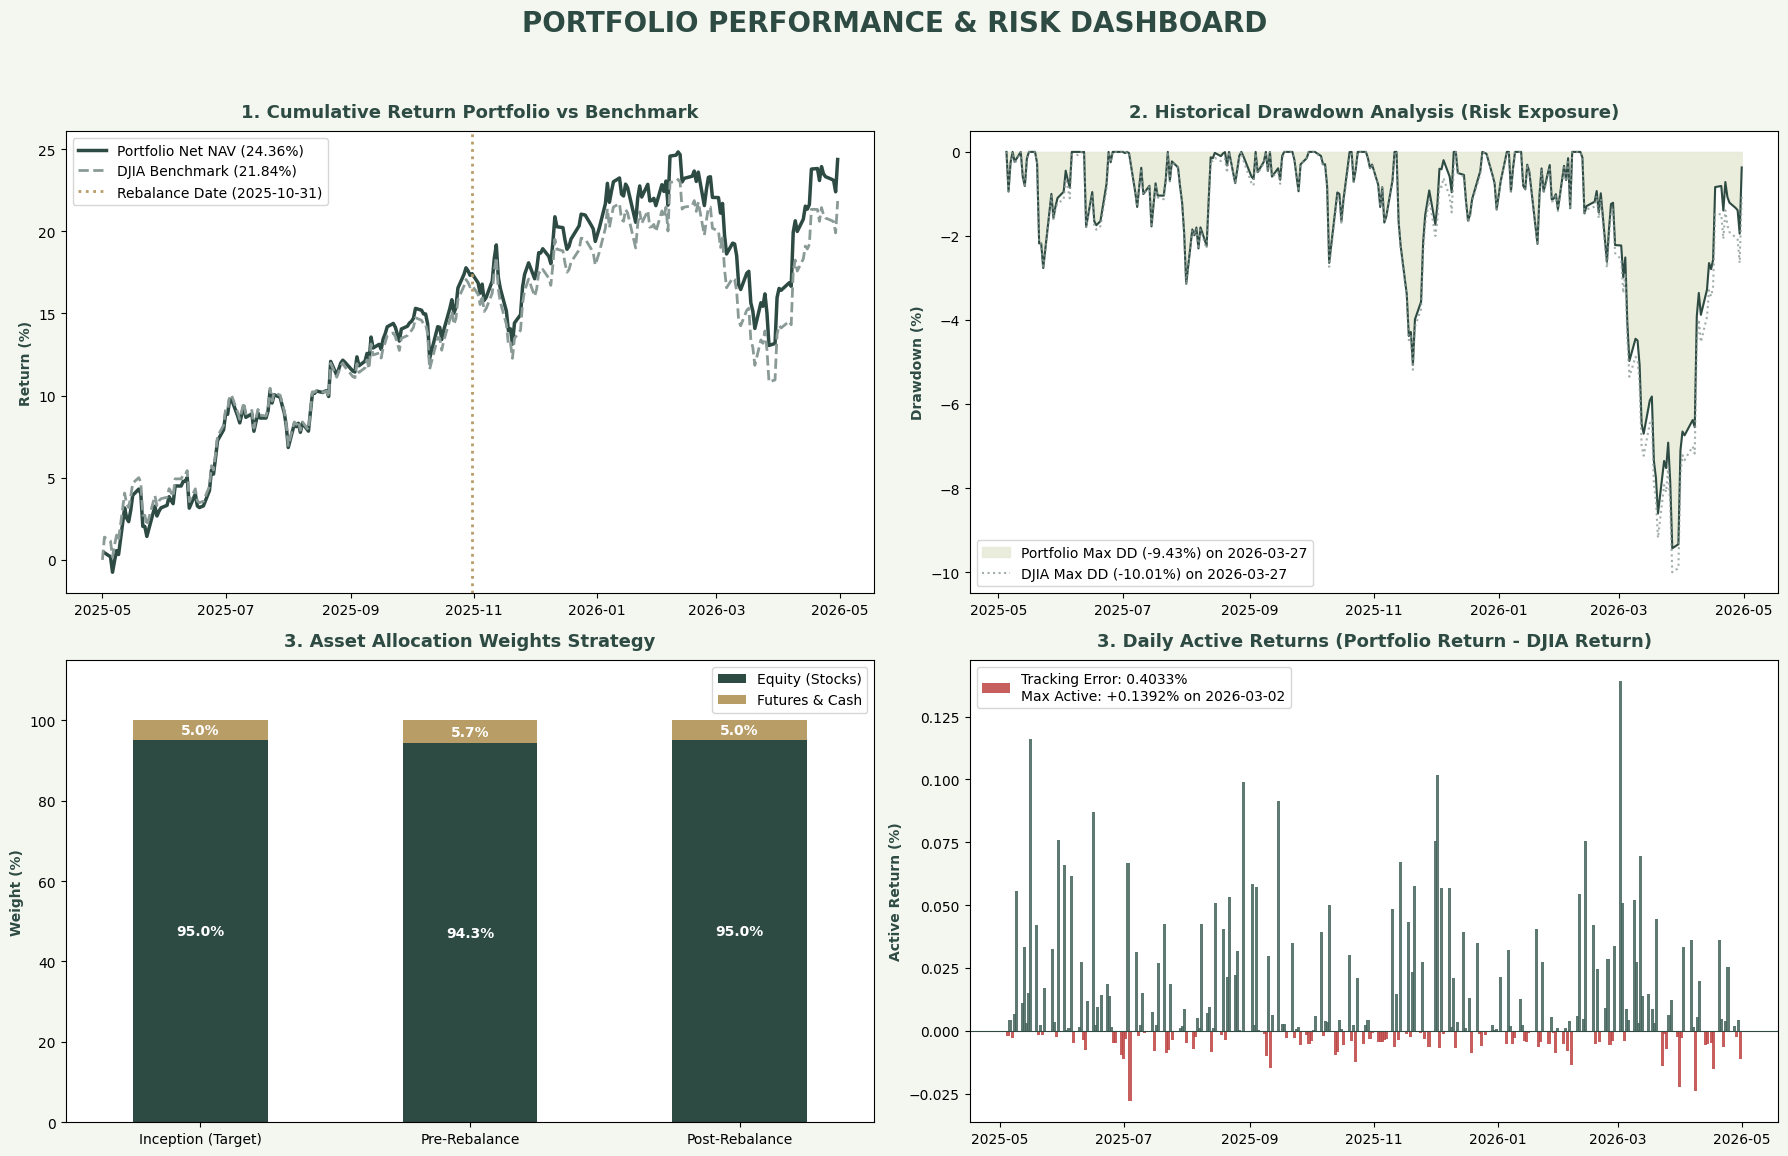

In [8]:
# 8. VISUALIZATION (FULL PORTFOLIO DASHBOARD)

import matplotlib.pyplot as plt
import seaborn as sns

# Set up a visual interface using the AG Capital color scheme
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.facecolor'] = '#f4f6f0'

# Create a dashboard with 4 charts (2 rows x 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('PORTFOLIO PERFORMANCE & RISK DASHBOARD', fontsize=20, fontweight='bold', color='#2d4a43', y=0.96)

# CHART 1: CUMULATIVE RETURN COMPARISON

ax1 = axes[0, 0]
ax1.set_facecolor('#ffffff')
port_cum = (df_risk['Net_NAV'] / CAPITAL) - 1
bench_cum = (data['^DJI'] / data['^DJI'].iloc[0]) - 1

ax1.plot(port_cum.index, port_cum * 100, label=f"Portfolio Net NAV ({portfolio_net_return*100:.2f}%)", color='#2d4a43', linewidth=2.5)
ax1.plot(bench_cum.index, bench_cum * 100, label=f"DJIA Benchmark ({benchmark_total_return*100:.2f}%)", color='#8a9a96', linestyle='--', linewidth=2)
ax1.axvline(x=pd.to_datetime(actual_rebal_dt), color='#b89d67', linestyle=':', linewidth=2, label=f'Rebalance Date ({actual_rebal_dt.date()})')

ax1.set_title('1. Cumulative Return Portfolio vs Benchmark', fontsize=13, fontweight='bold', color='#2d4a43', pad=10)
ax1.set_ylabel('Return (%)', fontweight='bold', color='#2d4a43')
ax1.legend(loc='upper left', frameon=True)

# CHART 2: DRAWDOWN AREA CHART

ax2 = axes[0, 1]
ax2.set_facecolor('#ffffff')
def get_drawdown_series(return_series):
    cum = (1 + return_series).cumprod()
    rolling_max = cum.cummax()
    return (cum - rolling_max) / rolling_max

port_dd = get_drawdown_series(port_net_returns)
bench_dd = get_drawdown_series(bench_returns)

# Specific date information for Max Drawdown in Legend display
ax2.fill_between(port_dd.index, port_dd * 100, 0, label=f'Portfolio Max DD ({mdd_port*100:.2f}%) on {mdd_port_date.date()}', color='#e8ebd9', alpha=0.9)
ax2.plot(port_dd.index, port_dd * 100, color='#2d4a43', linewidth=1.5)
ax2.plot(bench_dd.index, bench_dd * 100, label=f'DJIA Max DD ({mdd_bench*100:.2f}%) on {mdd_bench_date.date()}', color='#8a9a96', linestyle=':', alpha=0.8)

ax2.set_title('2. Historical Drawdown Analysis (Risk Exposure)', fontsize=13, fontweight='bold', color='#2d4a43', pad=10)
ax2.set_ylabel('Drawdown (%)', fontweight='bold', color='#2d4a43')
ax2.legend(loc='lower left', frameon=True)

# CHART 3: ASSET ALLOCATION REBALANCING

ax3 = axes[1, 0]
ax3.set_facecolor('#ffffff')
pre_eq_w = current_eq_w
pre_cash_w = 1.0 - pre_eq_w

allocation_data = {
    'Inception (Target)': [TARGET_EQ_W * 100, TARGET_FUT_CASH_W * 100],
    'Pre-Rebalance': [pre_eq_w * 100, pre_cash_w * 100],
    'Post-Rebalance': [actual_eq_weight_after * 100, (1 - actual_eq_weight_after) * 100]
}
df_alloc = pd.DataFrame(allocation_data, index=['Equity (Stocks)', 'Futures & Cash'])

df_alloc.T.plot(kind='bar', stacked=True, color=['#2d4a43', '#b89d67'], ax=ax3, width=0.5)
ax3.set_title('3. Asset Allocation Weights Strategy', fontsize=13, fontweight='bold', color='#2d4a43', pad=10)
ax3.set_ylabel('Weight (%)', fontweight='bold', color='#2d4a43')
ax3.set_ylim(0, 115)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)

for p in ax3.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax3.text(x + width/2, y + height/2, f'{height:.1f}%', color='white',
                 fontweight='bold', ha='center', va='center', fontsize=10)
ax3.legend(loc='upper right')

# CHART 4: DAILY ACTIVE RETURNS / TRACKING ERROR

ax4 = axes[1, 1]
ax4.set_facecolor('#ffffff')

# Find the exact date when Active Return reaches its highest positive value
max_active_val = active_return.max()
max_active_date = active_return.idxmax()

colors = ['#43635b' if x >= 0 else '#bf4343' for x in active_return]

ax4.bar(active_return.index, active_return * 100, color=colors, alpha=0.85, width=1.5,
        label=f'Tracking Error: {tracking_error_net*100:.4f}%\nMax Active: +{max_active_val*100:.4f}% on {max_active_date.date()}')
ax4.axhline(y=0, color='#2d4a43', linestyle='-', linewidth=0.8)

ax4.set_title('3. Daily Active Returns (Portfolio Return - DJIA Return)', fontsize=13, fontweight='bold', color='#2d4a43', pad=10)
ax4.set_ylabel('Active Return (%)', fontweight='bold', color='#2d4a43')
ax4.legend(loc='upper left', frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()
